# Simple Healthy-Only GANomaly for IDRiD + ODIR-5K + APTOS

This notebook implements **Stage 1 only**:

- Train on healthy images only: IDRiD `train/0`, `validation/0`, `test/0`, ODIR healthy images, and APTOS Grade 0.
- Reconstruct healthy fundus images with an encoder-decoder GANomaly model.
- Generate healthy-looking reconstructions from any input.
- Compute an anomaly score from latent error + reconstruction error.
- Send images above the calibrated threshold to Stage 2.

Important: this is a screening gate, not a diagnosis. Abnormal images are not supposed to be reconstructed faithfully, but this must be proven on an untouched test set. The notebook reports AUC, sensitivity, specificity, F1, confusion matrix, per-grade detection, and example reconstructions.

In [1]:
# Kaggle setup
!pip -q install albumentations==1.4.24 scikit-learn opencv-python-headless

import os, glob, random, math, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, f1_score, classification_report

print('Torch:', torch.__version__)
print('GPU:', torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.9/274.9 kB 6.0 MB/s eta 0:00:00a 0:00:01
Torch: 2.10.0+cu128
GPU: True Tesla T4


In [24]:
# Dataset paths

IDRID_ROOT = Path(
    "/kaggle/input/datasets/lakshmiprathik/idrid-516/IDRiD"
)

ODIR_ROOT = Path(
    "/kaggle/input/datasets/lakshmiprathik/odir-5k/ODIR-5K"
)

APTOS_ROOT = Path(
    "/kaggle/input/datasets/mariaherrerot/aptos2019"
)

APTOS_CSV = APTOS_ROOT / "train_1.csv"

# Change this only if your APTOS images are stored elsewhere.
APTOS_IMAGE_DIR = APTOS_ROOT / "train_images"

WORK = Path("/kaggle/working/ganomaly_simple")
CACHE = WORK / "cache"
CHECKPOINTS = WORK / "checkpoints"

WORK.mkdir(parents=True, exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)
CHECKPOINTS.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 100
LATENT = 128
LR = 2e-4
SEED = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything()

print("IDRiD root exists:", IDRID_ROOT.exists())
print("ODIR root exists:", ODIR_ROOT.exists())
print("APTOS root exists:", APTOS_ROOT.exists())
print("APTOS CSV exists:", APTOS_CSV.exists())
print("APTOS image folder exists:", APTOS_IMAGE_DIR.exists())
print("Device:", DEVICE)

IDRiD root exists: True
ODIR root exists: True
APTOS root exists: True
APTOS CSV exists: True
APTOS image folder exists: True
Device: cuda


## Dataset policy

The generator sees **only healthy images**. Grade 1-4 images are never used for generator training. They are used only for calibration/evaluation so the anomaly gate has a measurable operating point.

For ODIR, use the supplied healthy-image directory if present. Otherwise the loader searches common ODIR layouts and only accepts images whose filename is listed as normal in `full_df.csv` when available. APTOS is read from `train.csv` and filtered to diagnosis `0`.

In [25]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def all_images(root):
    return [
        p for p in Path(root).rglob("*")
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    ]


def idrid_rows():
    rows = []

    for split in ["train", "validation", "test"]:
        for grade in range(5):
            folder = IDRID_ROOT / split / str(grade)

            if not folder.exists():
                print("Missing IDRiD folder:", folder)
                continue

            for image_path in all_images(folder):
                rows.append({
                    "path": str(image_path),
                    "grade": grade,
                    "source": "idrid",
                    "split": split
                })

    return rows


def aptos_rows():
    rows = []

    if not APTOS_CSV.exists():
        raise FileNotFoundError(f"APTOS CSV not found: {APTOS_CSV}")

    if not APTOS_IMAGE_DIR.exists():
        raise FileNotFoundError(
            f"APTOS image directory not found: {APTOS_IMAGE_DIR}"
        )

    aptos_df = pd.read_csv(APTOS_CSV)

    required_columns = {"id_code", "diagnosis"}
    missing = required_columns - set(aptos_df.columns)

    if missing:
        raise ValueError(
            f"APTOS CSV is missing columns: {missing}. "
            f"Found columns: {list(aptos_df.columns)}"
        )

    print("APTOS columns:", list(aptos_df.columns))
    print("APTOS rows:", len(aptos_df))
    print("APTOS diagnosis counts:")
    print(aptos_df["diagnosis"].value_counts().sort_index())

    for row in aptos_df.itertuples(index=False):
        image_id = str(row.id_code)
        diagnosis = int(row.diagnosis)

        candidates = [
            APTOS_IMAGE_DIR / f"{image_id}.png",
            APTOS_IMAGE_DIR / f"{image_id}.jpg",
            APTOS_IMAGE_DIR / f"{image_id}.jpeg"
        ]

        image_path = next(
            (path for path in candidates if path.exists()),
            None
        )

        if image_path is not None:
            rows.append({
                "path": str(image_path),
                "grade": diagnosis,
                "source": "aptos",
                "split": "all"
            })

    print("APTOS images matched:", len(rows))
    return rows


def odir_rows():
    """
    ODIR folder contains only healthy images.
    No CSV is required.

    Every image found recursively under ODIR_ROOT
    is assigned:
        grade = 0
        label = healthy
    """

    image_paths = all_images(ODIR_ROOT)

    rows = [
        {
            "path": str(image_path),
            "grade": 0,
            "source": "odir",
            "split": "all"
        }
        for image_path in image_paths
    ]

    print("ODIR healthy images found:", len(rows))
    return rows   


# Build the complete index.
rows = []
rows.extend(idrid_rows())
rows.extend(aptos_rows())
rows.extend(odir_rows())

df = pd.DataFrame(rows)

if len(df) == 0:
    raise RuntimeError("No images were found. Check the dataset paths.")

df = df.drop_duplicates(subset="path").reset_index(drop=True)
df["label"] = (df["grade"] > 0).astype(int)

print("\nTotal unique images:", len(df))
print("\nImages by source and grade:")
display(pd.crosstab(df["source"], df["grade"]))

print("\nHealthy images:", int((df["label"] == 0).sum()))
print("Abnormal images:", int((df["label"] == 1).sum()))

APTOS columns: ['id_code', 'diagnosis']
APTOS rows: 2930
APTOS diagnosis counts:
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64
APTOS images matched: 0
ODIR healthy images found: 2873

Total unique images: 3389

Images by source and grade:


grade,0,1,2,3,4
source,,,,,
idrid,168,25,168,93,62
odir,2873,0,0,0,0



Healthy images: 3041
Abnormal images: 348


In [26]:
def crop_square(img):
    gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask=gray>7
    if mask.sum()>100:
        ys,xs=np.where(mask); img=img[ys.min():ys.max()+1,xs.min():xs.max()+1]
    h,w=img.shape[:2]; s=max(h,w)
    canvas=np.zeros((s,s,3),np.uint8)
    y=(s-h)//2; x=(s-w)//2; canvas[y:y+h,x:x+w]=img
    return canvas

def preprocess(path, size=IMG_SIZE):
    img=cv2.imread(str(path))
    if img is None: return np.zeros((size,size,3),np.uint8)
    img=crop_square(img)
    img=cv2.resize(img,(size,size),interpolation=cv2.INTER_AREA)
    # CLAHE on green channel, which carries most retinal lesion contrast.
    lab=cv2.cvtColor(img,cv2.COLOR_BGR2LAB); l,a,b=cv2.split(lab)
    l=cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8)).apply(l)
    img=cv2.cvtColor(cv2.merge([l,a,b]),cv2.COLOR_LAB2BGR)
    return img

def save_cache(frame):
    cached=[]
    for i,r in tqdm(frame.iterrows(),total=len(frame),desc='preprocessing'):
        out=CACHE/(str(i)+'.png')
        if not out.exists(): cv2.imwrite(str(out),preprocess(r.path))
        cached.append(str(out))
    frame=frame.copy(); frame['cache_path']=cached
    return frame
df=save_cache(df)

preprocessing:   0%|          | 0/3389 [00:00<?, ?it/s]

In [27]:
# Use IDRiD's declared split for IDRiD. For APTOS/ODIR, create deterministic splits.
def make_splits(frame):
    rng=np.random.RandomState(SEED)
    idr=frame[frame.source=='idrid']
    other=frame[frame.source!='idrid'].sample(frac=1,random_state=SEED)
    train_healthy=frame[(frame.label==0) & (frame.source.isin(['idrid','aptos','odir']))].sample(frac=1,random_state=SEED)
    # Hold out healthy images for calibration and final testing.
    n=len(train_healthy); ncal=max(50,int(.15*n)); ntest=max(100,int(.20*n))
    calib_h=train_healthy.iloc[:ncal]; test_h=train_healthy.iloc[ncal:ncal+ntest]; train_h=train_healthy.iloc[ncal+ntest:]
    # All IDRiD diseased images, plus any other known diseased images, are evaluation only.
    abnormal=frame[frame.label==1].sample(frac=1,random_state=SEED)
    ncal_p=min(max(50,int(.20*len(abnormal))),len(abnormal)//2)
    calib_p=abnormal.iloc[:ncal_p]; test_p=abnormal.iloc[ncal_p:]
    return {'train':train_h.reset_index(drop=True),
            'calib':pd.concat([calib_h,calib_p]).sample(frac=1,random_state=1).reset_index(drop=True),
            'test':pd.concat([test_h,test_p]).sample(frac=1,random_state=2).reset_index(drop=True)}
splits=make_splits(df)
for k,v in splits.items(): print(k,len(v),'healthy=',int((v.grade==0).sum()),'abnormal=',int((v.grade>0).sum()))
assert not (set(splits['train'].cache_path)&set(splits['calib'].cache_path))
assert not (set(splits['train'].cache_path)&set(splits['test'].cache_path))
assert not (set(splits['calib'].cache_path)&set(splits['test'].cache_path))
print('Leakage audit: PASSED')

train 1977 healthy= 1977 abnormal= 0
calib 525 healthy= 456 abnormal= 69
test 887 healthy= 608 abnormal= 279
Leakage audit: PASSED


In [28]:
class FundusDataset(Dataset):
    def __init__(self, frame, train=False): self.frame=frame.reset_index(drop=True); self.train=train
    def __len__(self): return len(self.frame)
    def __getitem__(self,i):
        r=self.frame.iloc[i]; img=cv2.cvtColor(cv2.imread(r.cache_path),cv2.COLOR_BGR2RGB)
        if self.train:
            if random.random()<.5: img=np.ascontiguousarray(img[:,::-1])
            if random.random()<.5: img=np.ascontiguousarray(img[::-1])
            if random.random()<.5:
                alpha=random.uniform(.9,1.1); beta=random.uniform(-10,10)
                img=np.clip(img.astype(np.float32)*alpha+beta,0,255).astype(np.uint8)
        x=torch.from_numpy(img.astype(np.float32)/127.5-1).permute(2,0,1)
        return x, int(r.grade), int(r.label), r.cache_path

train_loader=DataLoader(FundusDataset(splits['train'],True),batch_size=BATCH_SIZE,shuffle=True,num_workers=2,pin_memory=True,drop_last=True)

## GANomaly model

The generator has the standard one-class structure `Encoder -> latent -> Decoder -> Encoder`. The discriminator is used during training only. At inference, the device needs the generator and computes:

`anomaly_score = 0.5 * normalized latent error + 0.5 * normalized top-pixel reconstruction error`

The reconstructed image is the model's healthy estimate. It is useful for explainability, but **the score decides whether Stage 2 runs**.

In [29]:
class Encoder(nn.Module):
    def __init__(self, latent=LATENT):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv2d(3,32,4,2,1),nn.LeakyReLU(.2,True),
            nn.Conv2d(32,64,4,2,1),nn.BatchNorm2d(64),nn.LeakyReLU(.2,True),
            nn.Conv2d(64,128,4,2,1),nn.BatchNorm2d(128),nn.LeakyReLU(.2,True),
            nn.Conv2d(128,256,4,2,1),nn.BatchNorm2d(256),nn.LeakyReLU(.2,True),
            nn.Conv2d(256,latent,4,1,0))
    def forward(self,x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent=LATENT):
        super().__init__()
        self.net=nn.Sequential(
            nn.ConvTranspose2d(latent,256,4,1,0),nn.BatchNorm2d(256),nn.ReLU(True),
            nn.ConvTranspose2d(256,128,4,2,1),nn.BatchNorm2d(128),nn.ReLU(True),
            nn.ConvTranspose2d(128,64,4,2,1),nn.BatchNorm2d(64),nn.ReLU(True),
            nn.ConvTranspose2d(64,32,4,2,1),nn.BatchNorm2d(32),nn.ReLU(True),
            nn.ConvTranspose2d(32,3,4,2,1),nn.Tanh())
    def forward(self,z): return self.net(z)

class Generator(nn.Module):
    def __init__(self):
        super().__init__(); self.e1=Encoder(); self.g=Decoder(); self.e2=Encoder()
    def forward(self,x):
        z=self.e1(x); xhat=self.g(z); zhat=self.e2(xhat); return xhat,z,zhat

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__(); self.features=nn.Sequential(
            nn.Conv2d(3,32,4,2,1),nn.LeakyReLU(.2,True),
            nn.Conv2d(32,64,4,2,1),nn.BatchNorm2d(64),nn.LeakyReLU(.2,True),
            nn.Conv2d(64,128,4,2,1),nn.BatchNorm2d(128),nn.LeakyReLU(.2,True),
            nn.Conv2d(128,256,4,2,1),nn.BatchNorm2d(256),nn.LeakyReLU(.2,True))
        self.head=nn.Conv2d(256,1,8,1,0)
    def forward(self,x):
        f=self.features(x); return self.head(f).view(-1),f

G=Generator().to(DEVICE); D=Discriminator().to(DEVICE)
print('G params:',sum(p.numel() for p in G.parameters()),'D params:',sum(p.numel() for p in D.parameters()))

G params: 3646307 D params: 707425


In [31]:
def train_gan():
    optG = torch.optim.Adam(
        G.parameters(),
        LR,
        betas=(0.5, 0.999)
    )

    optD = torch.optim.Adam(
        D.parameters(),
        LR,
        betas=(0.5, 0.999)
    )

    AMP_ENABLED = (
        DEVICE == "cuda"
        or getattr(DEVICE, "type", None) == "cuda"
    )

    # Modern AMP API, with fallback for older PyTorch versions
    if hasattr(torch, "amp"):
        try:
            scaler = torch.amp.GradScaler(
                "cuda",
                enabled=AMP_ENABLED
            )
        except TypeError:
            scaler = torch.cuda.amp.GradScaler(
                enabled=AMP_ENABLED
            )
    else:
        scaler = torch.cuda.amp.GradScaler(
            enabled=AMP_ENABLED
        )

    def autocast_context():
        if hasattr(torch, "amp"):
            return torch.amp.autocast(
                device_type="cuda",
                enabled=AMP_ENABLED
            )

        return torch.cuda.amp.autocast(
            enabled=AMP_ENABLED
        )

    best_loss = float("inf")
    history = []

    for epoch in range(1, EPOCHS + 1):
        G.train()
        D.train()

        total_g_loss = 0.0
        total_d_loss = 0.0
        total_samples = 0

        progress_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch}/{EPOCHS}",
            leave=False
        )

        for x, _, _, _ in progress_bar:
            x = x.to(
                DEVICE,
                non_blocking=True
            )

            batch_size = x.size(0)

            # -------------------------------------------------
            # Discriminator update
            # -------------------------------------------------
            optD.zero_grad(set_to_none=True)

            with autocast_context():
                with torch.no_grad():
                    xhat, _, _ = G(x)

                real_logits, _ = D(x)
                fake_logits, _ = D(xhat.detach())

                lossD = (
                    F.relu(1.0 - real_logits).mean()
                    + F.relu(1.0 + fake_logits).mean()
                )

            scaler.scale(lossD).backward()
            scaler.step(optD)

            # -------------------------------------------------
            # Generator update
            # -------------------------------------------------
            optG.zero_grad(set_to_none=True)

            with autocast_context():
                xhat, z, zhat = G(x)

                _, real_features = D(x)
                _, fake_features = D(xhat)

                context_loss = F.l1_loss(
                    xhat,
                    x
                )

                latent_loss = F.mse_loss(
                    zhat,
                    z.detach()
                )

                feature_loss = F.mse_loss(
                    fake_features,
                    real_features.detach()
                )

                lossG = (
                    50.0 * context_loss
                    + 1.0 * latent_loss
                    + 1.0 * feature_loss
                )

            scaler.scale(lossG).backward()
            scaler.step(optG)
            scaler.update()

            total_g_loss += lossG.item() * batch_size
            total_d_loss += lossD.item() * batch_size
            total_samples += batch_size

            progress_bar.set_postfix({
                "G": f"{lossG.item():.3f}",
                "D": f"{lossD.item():.3f}"
            })

        mean_g_loss = total_g_loss / max(1, total_samples)
        mean_d_loss = total_d_loss / max(1, total_samples)

        history.append({
            "epoch": epoch,
            "lossG": mean_g_loss,
            "lossD": mean_d_loss
        })

        # Save the best reconstruction checkpoint
        if mean_g_loss < best_loss:
            best_loss = mean_g_loss

            torch.save(
                {
                    "G": G.state_dict(),
                    "D": D.state_dict(),
                    "epoch": epoch,
                    "lossG": mean_g_loss,
                    "lossD": mean_d_loss
                },
                CHECKPOINTS / "ganomaly_simple_best.pt"
            )

        print(
            f"Epoch {epoch:03d}/{EPOCHS} | "
            f"G={mean_g_loss:.5f} | "
            f"D={mean_d_loss:.5f}"
        )

    # Save training history
    history_df = pd.DataFrame(history)
    history_df.to_csv(
        WORK / "history.csv",
        index=False
    )

    # -------------------------------------------------
    # Load best checkpoint
    # -------------------------------------------------
    checkpoint = torch.load(
        CHECKPOINTS / "ganomaly_simple_best.pt",
        map_location=DEVICE
    )

    G.load_state_dict(checkpoint["G"])
    D.load_state_dict(checkpoint["D"])

    G.eval()
    D.eval()

    print(
        f"\nBest checkpoint loaded from epoch "
        f"{checkpoint['epoch']}"
    )
train_gan()

Epoch 1/100:   0%|          | 0/61 [00:00<?, ?it/s]

Epoch 001/100 | G=17.42904 | D=0.13559


Epoch 2/100:   0%|          | 0/61 [00:00<?, ?it/s]

Epoch 002/100 | G=7.83439 | D=0.02446


Epoch 3/100:   0%|          | 0/61 [00:00<?, ?it/s]

...

Epoch 098/100 | G=2.81045 | D=0.00000


Epoch 99/100:   0%|          | 0/61 [00:00<?, ?it/s]

Epoch 099/100 | G=2.82633 | D=0.00000


Epoch 100/100:   0%|          | 0/61 [00:00<?, ?it/s]

Epoch 100/100 | G=2.80355 | D=0.00000

Best checkpoint loaded from epoch 95


In [32]:
@torch.no_grad()
def raw_scores(frame):
    G.eval(); loader=DataLoader(FundusDataset(frame),batch_size=BATCH_SIZE*2,num_workers=2)
    rows=[]
    for x,grade,label,paths in tqdm(loader,desc='scoring'):
        x=x.to(DEVICE)
        xhat,z,zhat=G(x)
        latent=((z-zhat)**2).mean((1,2,3))
        residual=(x-xhat).abs().mean(1)
        flat=residual.flatten(1)
        k=max(1,int(.01*flat.shape[1]))
        top=flat.topk(k,dim=1).values.mean(1)
        mean=flat.mean(1)
        for p,g,y,l,t,m in zip(paths,grade.numpy(),label.numpy(),latent.cpu(),top.cpu(),mean.cpu()):
            rows.append({'path':p,'grade':int(g),'label':int(y),'latent':float(l),'top_residual':float(t),'mean_residual':float(m)})
    return pd.DataFrame(rows)

calib=raw_scores(splits['calib']); test=raw_scores(splits['test'])
# Fit normalisation using healthy calibration images only.
healthy=calib[calib.label==0]
params={}
for c in ['latent','top_residual','mean_residual']:
    med=healthy[c].median(); scale=healthy[c].quantile(.75)-healthy[c].quantile(.25)+1e-8; params[c]=(med,scale)
for out in [calib,test]:
    for c,(med,scale) in params.items(): out[c+'_z']=(out[c]-med)/scale
calib['score']=.5*calib.latent_z+.5*calib.top_residual_z
test['score']=.5*test.latent_z+.5*test.top_residual_z
print('Calibration AUC:',roc_auc_score(calib.label,calib.score),'Test AUC:',roc_auc_score(test.label,test.score))

scoring:   0%|          | 0/9 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782c4c078680><function _MultiProcessingDataLoaderIter.__del__ at 0x782c4c078680>Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782c4c078680>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1653, in _shutdown_workers
    self._pin_memory_thread.join()
  File "/usr/lib/python3.12/threading.py", line 1146, in join
    raise RuntimeError("cannot join current thread")
RuntimeError: cannot join current thread


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 

scoring:   0%|          | 0/14 [00:00<?, ?it/s]

Calibration AUC: 0.8827866768370201 Test AUC: 0.9093036691190342


In [34]:
def choose_threshold(y,s):
    fpr,tpr,thr=roc_curve(y,s); j=tpr-fpr; i=int(np.argmax(j)); return float(thr[i]),float(tpr[i]),float(1-fpr[i])

def metrics(y,s,t):
    p=(s>t).astype(int); tn,fp,fn,tp=confusion_matrix(y,p,labels=[0,1]).ravel()
    sens=tp/max(1,tp+fn); spec=tn/max(1,tn+fp); f1=f1_score(y,p,zero_division=0)
    return {'threshold':t,'sensitivity':sens,'specificity':spec,'f1':f1,'tp':tp,'fp':fp,'fn':fn,'tn':tn}

thr,j_sens,j_spec=choose_threshold(calib.label.values,calib.score.values)
print('Youden threshold:',thr,'calibration sensitivity:',j_sens,'specificity:',j_spec)
print('HELD-OUT TEST:',metrics(test.label.values,test.score.values,thr))

# Also print the best threshold that reaches at least 85% sensitivity on calibration.
fpr,tpr,thresholds=roc_curve(calib.label,calib.score); candidates=np.where(tpr>=.85)[0]
if len(candidates):
    i=candidates[np.argmax(1-fpr[candidates])]; thr85=float(thresholds[i]); print('85% sensitivity calibration threshold:',thr85); print('TEST:',metrics(test.label.values,test.score.values,thr85))

print(pd.crosstab(test.grade,test.score>thr).rename(columns={False:'normal_gate',True:'send_stage2'}))

Youden threshold: 0.6281980502026594 calibration sensitivity: 0.8985507246376812 specificity: 0.7850877192982456
HELD-OUT TEST: {'threshold': 0.6281980502026594, 'sensitivity': np.float64(0.8458781362007168), 'specificity': np.float64(0.8174342105263158), 'f1': 0.7539936102236422, 'tp': np.int64(236), 'fp': np.int64(111), 'fn': np.int64(43), 'tn': np.int64(497)}
85% sensitivity calibration threshold: 0.6971779219539039
TEST: {'threshold': 0.6971779219539039, 'sensitivity': np.float64(0.8207885304659498), 'specificity': np.float64(0.8421052631578947), 'f1': 0.7582781456953642, 'tp': np.int64(229), 'fp': np.int64(96), 'fn': np.int64(50), 'tn': np.int64(512)}
score  normal_gate  send_stage2
grade                          
0              497          111
1                6           13
2               25          107
3                7           68
4                5           48


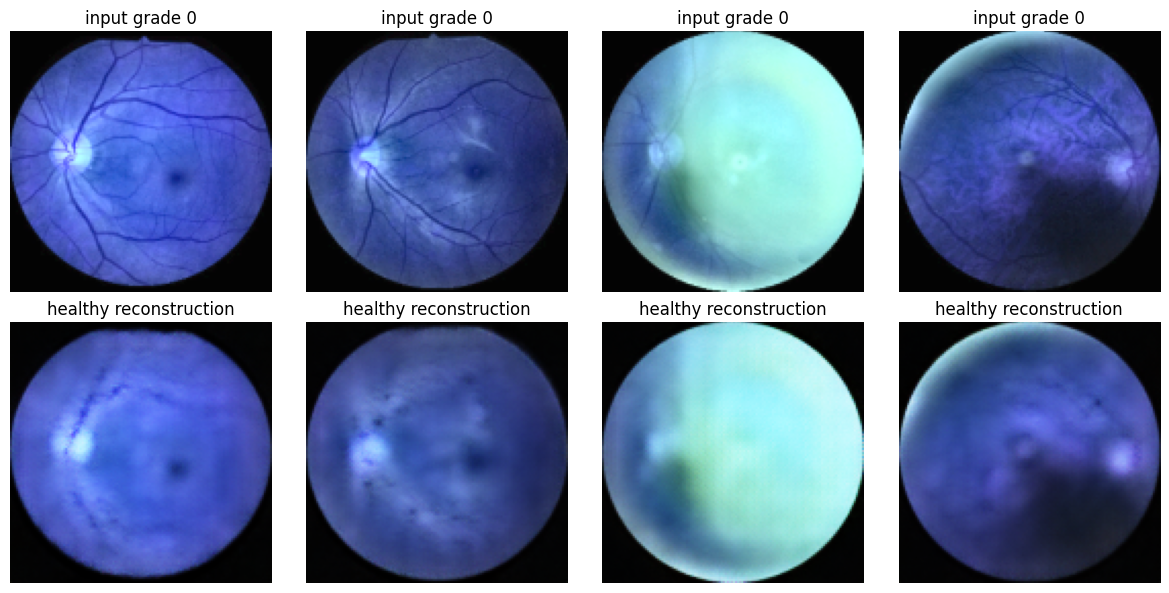

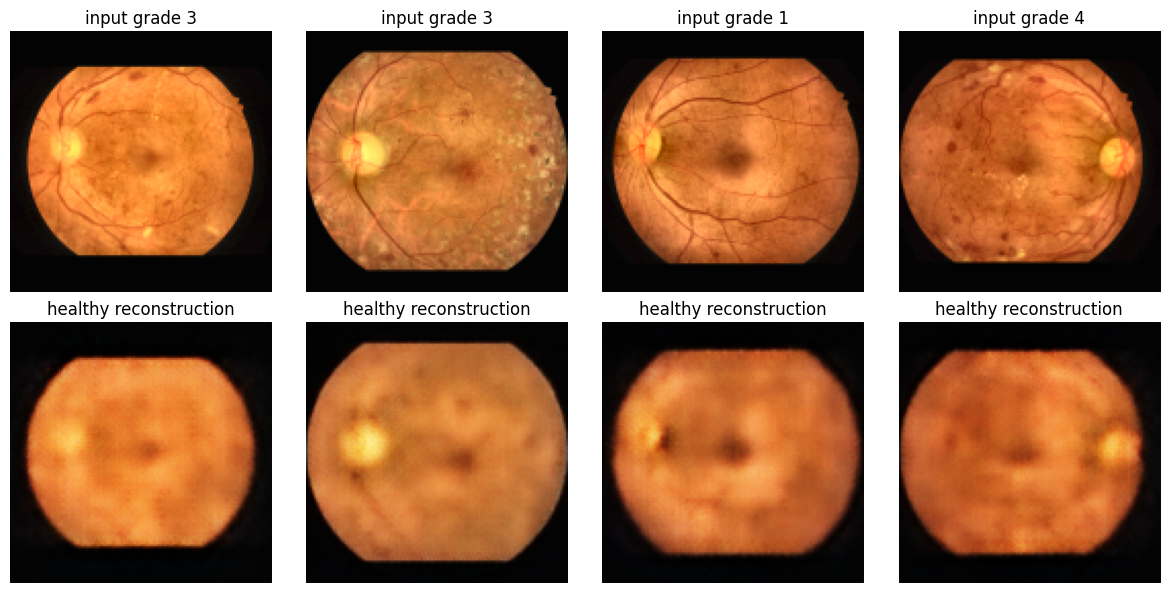

In [35]:
# Visualise healthy generation and abnormal failure.
def show_examples(frame,n=5):
    sample=frame.sample(min(n,len(frame)),random_state=3); loader=DataLoader(FundusDataset(sample),batch_size=len(sample))
    x,grade,label,paths=next(iter(loader));
    with torch.no_grad(): xhat,_,_=G(x.to(DEVICE))
    x=x.numpy().transpose(0,2,3,1); xhat=xhat.cpu().numpy().transpose(0,2,3,1)
    x=(x+1)/2; xhat=(xhat+1)/2
    fig,ax=plt.subplots(2,len(sample),figsize=(3*len(sample),6)); ax=np.atleast_2d(ax)
    for i in range(len(sample)):
        ax[0,i].imshow(np.clip(x[i],0,1)); ax[0,i].set_title(f'input grade {int(grade[i])}')
        ax[1,i].imshow(np.clip(xhat[i],0,1)); ax[1,i].set_title('healthy reconstruction')
        ax[0,i].axis('off'); ax[1,i].axis('off')
    plt.tight_layout(); plt.show()
show_examples(splits['test'][splits['test'].grade==0],4)
show_examples(splits['test'][splits['test'].grade>0],4)

In [36]:
# Save artifacts for Stage 2 integration.
config={'img_size':IMG_SIZE,'latent':LATENT,'threshold_youden':thr,'preprocessing':'crop + CLAHE + resize','score':'0.5 latent z-score + 0.5 top-1-percent residual z-score'}
with open(WORK/'stage1_config.json','w') as f: json.dump(config,f,indent=2)
calib.to_csv(WORK/'calibration_scores.csv',index=False); test.to_csv(WORK/'test_scores.csv',index=False)
print('Checkpoint:',CHECKPOINTS/'ganomaly_simple_best.pt')
print('Stage 2 rule: if anomaly_score > threshold, forward original image and score to the severity model.')

Checkpoint: /kaggle/working/ganomaly_simple/checkpoints/ganomaly_simple_best.pt
Stage 2 rule: if anomaly_score > threshold, forward original image and score to the severity model.


In [ ]:
# Single-image GANomaly inference: show reconstruction + decide Stage 2
# Reuses what the earlier cells already define:
#   G          -> trained generator (returns xhat, z, zhat)
#   preprocess -> same crop + CLAHE + resize used in training
#   params     -> z-score normalisation fitted on healthy calibration images
#   thr        -> calibrated Youden threshold

# --- 1) pick one image path here ---
img_path = "/kaggle/input/datasets/lakshmiprathik/idrid-516/IDRiD/test/4/IDRiD_001.jpg"

# Fall back to an abnormal test image if the path above does not exist here.
if not Path(img_path).exists():
    img_path = splits["test"][splits["test"].grade > 0].iloc[0].path
    print("Path not found, using test image instead:", img_path)

@torch.no_grad()
def infer_one(path):
    # Same preprocessing as training: crop + CLAHE + resize to IMG_SIZE, scaled to [-1, 1].
    img = cv2.cvtColor(preprocess(path), cv2.COLOR_BGR2RGB)
    x = torch.from_numpy(img.astype(np.float32) / 127.5 - 1).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    G.eval()
    xhat, z, zhat = G(x)

    # Same anomaly score as the evaluation cells:
    # 0.5 * latent z-score + 0.5 * top-1%-residual z-score
    latent = ((z - zhat) ** 2).mean().item()
    flat = (x - xhat).abs().mean(1).flatten(1)
    k = max(1, int(0.01 * flat.shape[1]))
    top = flat.topk(k, dim=1).values.mean().item()
    latent_z = (latent - params["latent"][0]) / params["latent"][1]
    top_z = (top - params["top_residual"][0]) / params["top_residual"][1]
    score = 0.5 * latent_z + 0.5 * top_z

    # Back to [0, 1] for display.
    x_np = np.clip((x.squeeze(0).cpu().numpy().transpose(1, 2, 0) + 1) / 2, 0, 1)
    r_np = np.clip((xhat.squeeze(0).cpu().numpy().transpose(1, 2, 0) + 1) / 2, 0, 1)

    decision = "GO TO STAGE 2" if score > thr else "NORMAL, stop here"

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(x_np)
    ax[0].set_title("Original")
    ax[0].axis("off")
    ax[1].imshow(r_np)
    ax[1].set_title("Healthy reconstruction")
    ax[1].axis("off")
    plt.tight_layout()
    plt.show()

    print(f"Image:         {path}")
    print(f"Anomaly score: {score:.4f}")
    print(f"Threshold:     {thr:.4f}")
    print(f"Decision:      {decision}")

infer_one(img_path)


## What this first working version proves

1. The GAN learns the healthy distribution from `grade 0` only.
2. It produces a healthy reconstruction for normal fundus images.
3. Grade 1-4 images are scored as anomalies when their reconstruction/latent errors exceed the threshold.
4. The threshold is learned from calibration data, not guessed.
5. The test metrics are computed only after calibration, so they are not used to choose the operating point.

Do **not** claim clinical performance from this notebook alone. Before rural testing, repeat the evaluation on an untouched Indian clinic dataset, measure image-quality failure separately, quantize the generator, recalibrate the threshold after quantization, and keep a manual ophthalmologist review path.